=== Data Descriptive Statistics ===
           estimated_duration              estimated_budget       
                        count   mean   std             mean    std
complexity                                                        
1                        1413   6.48  1.70           213.69  56.19
2                        1714   9.45  1.69           340.24  60.79
3                        1998  12.48  1.72           486.78  67.04
4                        1971  15.53  1.68           652.08  70.45
5                        2904  18.52  1.72           833.40  77.28

=== Model Evaluation Results ===
Duration Model - R² Score: 0.860, RMSE: 1.71
Budget Model - R² Score: 0.912, RMSE: $68.39

=== Model Function Expressions ===

=== Duration Expression ===
Polynomial degree: 2
Formula: Duration = 3.53 + 2.94*complexity + 0.01*complexity^2
Coefficients:
  complexity: 2.9441
  complexity^2: 0.0120

=== Budget Expression ===
Polynomial degree: 2
Formula: Budget = 106.21 + 98.30*complexity + 9.4

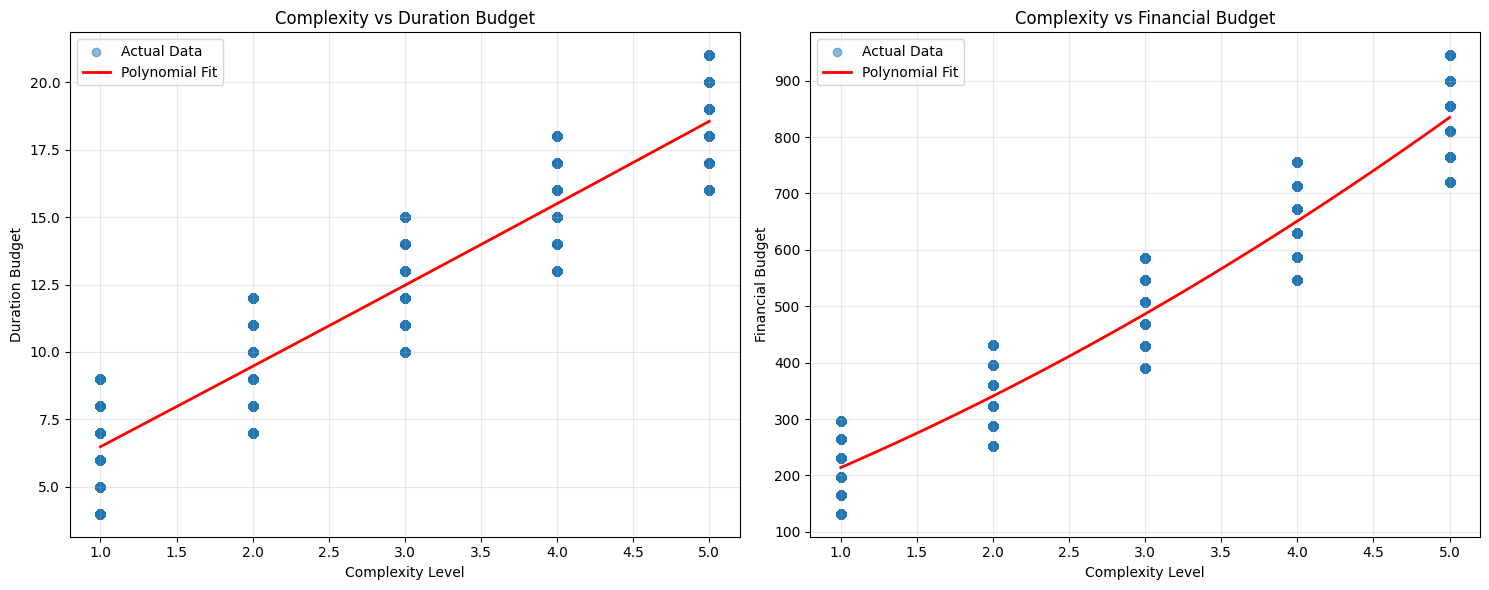


=== Testing Loaded Models ===

Models loaded from duration_model.pkl and budget_model.pkl
Prediction using loaded models (complexity=3): {'Complexity': 3, 'Predicted Duration': 12.5, 'Predicted Budget': 486.44}

Bulk Prediction Summary (using loaded models):
 Complexity  Predicted Duration  Predicted Budget
          1                 6.5            213.99
          2                 9.5            340.73
          3                12.5            486.44
          4                15.5            651.11
          5                18.6            834.74


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df = pd.read_csv('tasks.csv')

data = df[['complexity', 'estimated_duration', 'estimated_budget']].dropna()

print("=== Data Descriptive Statistics ===")
stats = data.groupby('complexity').agg({
    'estimated_duration': ['count', 'mean', 'std'],
    'estimated_budget': ['mean', 'std']
}).round(2)
print(stats)

X = data[['complexity']]
y_duration = data['estimated_duration']
y_budget = data['estimated_budget']

X_train, X_test, y_duration_train, y_duration_test = train_test_split(
    X, y_duration, test_size=0.2, random_state=42
)
X_train, X_test, y_budget_train, y_budget_test = train_test_split(
    X, y_budget, test_size=0.2, random_state=42
)

degree = 2

duration_model = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('linear', LinearRegression())
])
duration_model.fit(X_train, y_duration_train)

budget_model = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('linear', LinearRegression())
])
budget_model.fit(X_train, y_budget_train)

def evaluate_models():
    duration_pred_test = duration_model.predict(X_test)
    duration_mse = mean_squared_error(y_duration_test, duration_pred_test)
    duration_r2 = r2_score(y_duration_test, duration_pred_test)
    
    budget_pred_test = budget_model.predict(X_test)
    budget_mse = mean_squared_error(y_budget_test, budget_pred_test)
    budget_r2 = r2_score(y_budget_test, budget_pred_test)
    
    print("\n=== Model Evaluation Results ===")
    print(f"Duration Model - R² Score: {duration_r2:.3f}, RMSE: {np.sqrt(duration_mse):.2f}")
    print(f"Budget Model - R² Score: {budget_r2:.3f}, RMSE: ${np.sqrt(budget_mse):.2f}")
    
    return duration_r2, budget_r2

def save_models(duration_path='duration_model.pkl', budget_path='budget_model.pkl'):
    joblib.dump(duration_model, duration_path)
    joblib.dump(budget_model, budget_path)
    print(f"\nModels saved to {duration_path} and {budget_path}")

def load_models(duration_path='duration_model.pkl', budget_path='budget_model.pkl'):
    loaded_duration_model = joblib.load(duration_path)
    loaded_budget_model = joblib.load(budget_path)
    print(f"\nModels loaded from {duration_path} and {budget_path}")
    return loaded_duration_model, loaded_budget_model


def get_model_expression(model, model_name):
    poly = model.named_steps['poly']
    linear = model.named_steps['linear']
    
    feature_names = poly.get_feature_names_out(['complexity'])
    
    coef = linear.coef_
    intercept = linear.intercept_
    
    terms = []
    coef_dict = {}
    
    if abs(intercept) > 1e-6:
        terms.append(f"{intercept:.2f}")
    
    for i, (name, c) in enumerate(zip(feature_names, coef)):
        if abs(c) > 1e-6:
            coef_dict[name] = c
            if i == 0:
                if abs(intercept) < 1e-6:
                    terms.append(f"{c:.2f}")
            else:
                if c > 0:
                    terms.append(f"+ {c:.2f}*{name}")
                else:
                    terms.append(f"- {abs(c):.2f}*{name}")
    
    expression = f"{model_name} = " + " ".join(terms)
    
    print(f"\n=== {model_name} Expression ===")
    print(f"Polynomial degree: {poly.degree}")
    print(f"Formula: {expression}")
    print("Coefficients:")
    for name, c in coef_dict.items():
        print(f"  {name}: {c:.4f}")
    
    return expression, coef_dict


def predict_resources(complexity_level, duration_model, budget_model):
    """
    Input complexity level (1-5), return predicted duration and budget
    """
    if not 1 <= complexity_level <= 5:
        return "Error: Complexity must be between 1 and 5"
    
    # Use DataFrame format consistent with training data
    X_pred = pd.DataFrame([[complexity_level]], columns=['complexity'])
    
    duration_pred = duration_model.predict(X_pred)[0]
    budget_pred = budget_model.predict(X_pred)[0]
    
    return {
        'Complexity': complexity_level,
        'Predicted Duration': float(round(duration_pred, 1)),
        'Predicted Budget': float(round(budget_pred, 2))
    }


def plot_results(duration_model, budget_model):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Duration Budget Scatter and Fit
    axes[0].scatter(X, y_duration, alpha=0.5, label='Actual Data')
    X_range = pd.DataFrame({'complexity': np.linspace(1, 5, 100)})
    y_duration_range = duration_model.predict(X_range)
    axes[0].plot(X_range, y_duration_range, color='red', linewidth=2, label='Polynomial Fit')
    axes[0].set_xlabel('Complexity Level')
    axes[0].set_ylabel('Duration Budget')
    axes[0].set_title('Complexity vs Duration Budget')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Financial Budget Scatter and Fit
    axes[1].scatter(X, y_budget, alpha=0.5, label='Actual Data')
    y_budget_range = budget_model.predict(X_range)
    axes[1].plot(X_range, y_budget_range, color='red', linewidth=2, label='Polynomial Fit')
    axes[1].set_xlabel('Complexity Level')
    axes[1].set_ylabel('Financial Budget')
    axes[1].set_title('Complexity vs Financial Budget')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    evaluate_models()
    
    print("\n=== Model Function Expressions ===")
    duration_expr, duration_coefs = get_model_expression(duration_model, "Duration")
    budget_expr, budget_coefs = get_model_expression(budget_model, "Budget")
    
    save_models()
    
    print("\n=== Prediction Results (Current Model) ===")
    for level in range(1, 6):
        result = predict_resources(level, duration_model, budget_model)
        print(result)
    
    plot_results(duration_model, budget_model)







    
    print("\n=== Testing Loaded Models ===")
    loaded_duration_model, loaded_budget_model = load_models()
    
    test_complexity = 3
    result_loaded = predict_resources(test_complexity, loaded_duration_model, loaded_budget_model)
    print(f"Prediction using loaded models (complexity={test_complexity}): {result_loaded}")

    complexities = [1, 2, 3, 4, 5]
    predictions = [predict_resources(c, loaded_duration_model, loaded_budget_model) for c in complexities]
    df_pred = pd.DataFrame(predictions)
    print("\nBulk Prediction Summary (using loaded models):")
    print(df_pred.to_string(index=False))

In [3]:
import pandas as pd
import joblib

def predict_from_model(complexity_level, duration_model_path='duration_model.pkl', budget_model_path='budget_model.pkl'):
    if not (1 <= complexity_level <= 5):
        return {"error": "Complexity must be between 1 and 5"}
    
    try:
        duration_model = joblib.load(duration_model_path)
        budget_model = joblib.load(budget_model_path)
    except FileNotFoundError:
        return {"error": "Model files not found. Run training first."}
    
    X_pred = pd.DataFrame([[complexity_level]], columns=['complexity'])
    
    try:
        duration_pred = duration_model.predict(X_pred)[0]
        budget_pred = budget_model.predict(X_pred)[0]
        
        return {
            'complexity': int(complexity_level),
            'predicted_duration': float(round(duration_pred, 1)),
            'predicted_budget': float(round(budget_pred, 2))
        }
    except Exception as e:
        return {"error": str(e)}

if __name__ == "__main__":
    result = predict_from_model(5)
    print(result)

{'complexity': 5, 'predicted_duration': 18.6, 'predicted_budget': 834.74}
